In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_merged_players.csv')

In [3]:
df.head()

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,...,avg_clearances,avg_clangers,avg_free_kicks_for,avg_free_kicks_against,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_one_percenters,avg_score,avg_fantasy_points
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,2.7,3.3,0.7,2.0,6.7,6.7,0.3,4.3,6.7,92.7
1,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,0.0,3.0,0.0,2.0,2.0,3.0,1.0,5.0,1.0,61.0
2,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,3.0,4.0,1.0,3.0,6.0,8.0,0.0,3.0,6.0,74.0
3,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,6.0,22.0
4,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,...,1.1,0.9,0.6,0.1,5.7,3.0,0.3,1.0,5.3,36.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25074 entries, 0 to 25073
Data columns (total 58 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           25074 non-null  int64  
 1   player_name                  25074 non-null  object 
 2   player_full_name             25074 non-null  object 
 3   first_name                   25074 non-null  object 
 4   last_name                    25074 non-null  object 
 5   born_date                    25074 non-null  object 
 6   debut_date                   25074 non-null  object 
 7   debut_age                    25074 non-null  int64  
 8   last_date                    25074 non-null  object 
 9   last_age                     25074 non-null  int64  
 10  height                       25074 non-null  int64  
 11  weight                       25074 non-null  int64  
 12  player_link                  25074 non-null  object 
 13  player_teams    

In [5]:
df.isnull().sum()

,0
id,0
player_name,0
player_full_name,0
first_name,0
last_name,0
born_date,0
debut_date,0
debut_age,0
last_date,0
last_age,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(25074, 58)

Now I have checked that the data set is clean from above lines of code so I move on to next step

#Question 1
Which Teams have played the most games?

In [11]:
#finding the exact number of games each team has played
team_games=df.groupby('team')['games_played'].sum().sort_values(ascending=False).reset_index()
team_games_columns=['team','total_games_played']
print(team_games.to_string)

<bound method DataFrame.to_string of                              team  games_played
0                    geelong cats         16834
1               west coast eagles         16495
2                essendon bombers         16462
3       north melbourne kangaroos         16336
4             collingwood magpies         16298
5                    sydney swans         16165
6                 st kilda saints         16116
7                western bulldogs         16080
8                  adelaide crows         16018
9                 richmond tigers         15968
10                  carlton blues         15968
11               melbourne demons         15614
12                 hawthorn hawks         15576
13              fremantle dockers         14946
14                 brisbane lions         14929
15            port adelaide power         14729
16                gold coast suns          7375
17  greater western sydney giants          7271
18                 brisbane bears          1469
19 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'geelong cats'),
  Text(1, 0, 'west coast eagles'),
  Text(2, 0, 'essendon bombers'),
  Text(3, 0, 'north melbourne kangaroos'),
  Text(4, 0, 'collingwood magpies'),
  Text(5, 0, 'sydney swans'),
  Text(6, 0, 'st kilda saints'),
  Text(7, 0, 'western bulldogs'),
  Text(8, 0, 'adelaide crows'),
  Text(9, 0, 'richmond tigers'),
  Text(10, 0, 'carlton blues'),
  Text(11, 0, 'melbourne demons'),
  Text(12, 0, 'hawthorn hawks'),
  Text(13, 0, 'fremantle dockers'),
  Text(14, 0, 'brisbane lions'),
  Text(15, 0, 'port adelaide power'),
  Text(16, 0, 'gold coast suns'),
  Text(17, 0, 'greater western sydney giants'),
  Text(18, 0, 'brisbane bears'),
  Text(19, 0, 'fitzroy lions')])

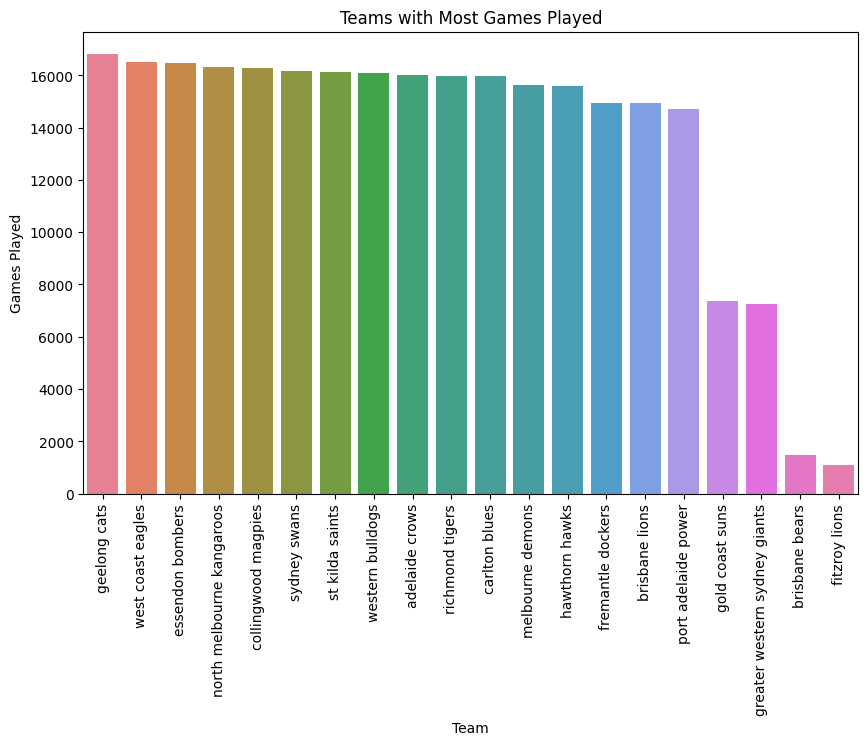

In [9]:
team_games=df.groupby('team')['games_played'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=team_games,x='team',y='games_played',hue='team')
plt.title('Teams with Most Games Played')
plt.xlabel('Team')
plt.ylabel('Games Played')
plt.xticks(rotation=90)

#Observations
1.   Team Geelong Cats have played the most games and their game count is 16834.
2.   Team with the least number of games played is fitzroy lions with only 1078 matches.
1.   In short we can say that older clubs have played significant amount of more games than the newer clubs.

#Business Insight
Total games played only defines that how long the club has been existed in the competition, Not for how well it performs. So, this should not be considered when you are evaluating the team strength.



#Question Number 2
What is the distribution of player ages?

In [25]:
df["last_age"].value_counts().sort_index()

,count
last_age,
18,34
19,156
20,367
21,500
22,823
23,1045
24,1140
25,1322
26,1496


Text(0, 0.5, 'Frequency')

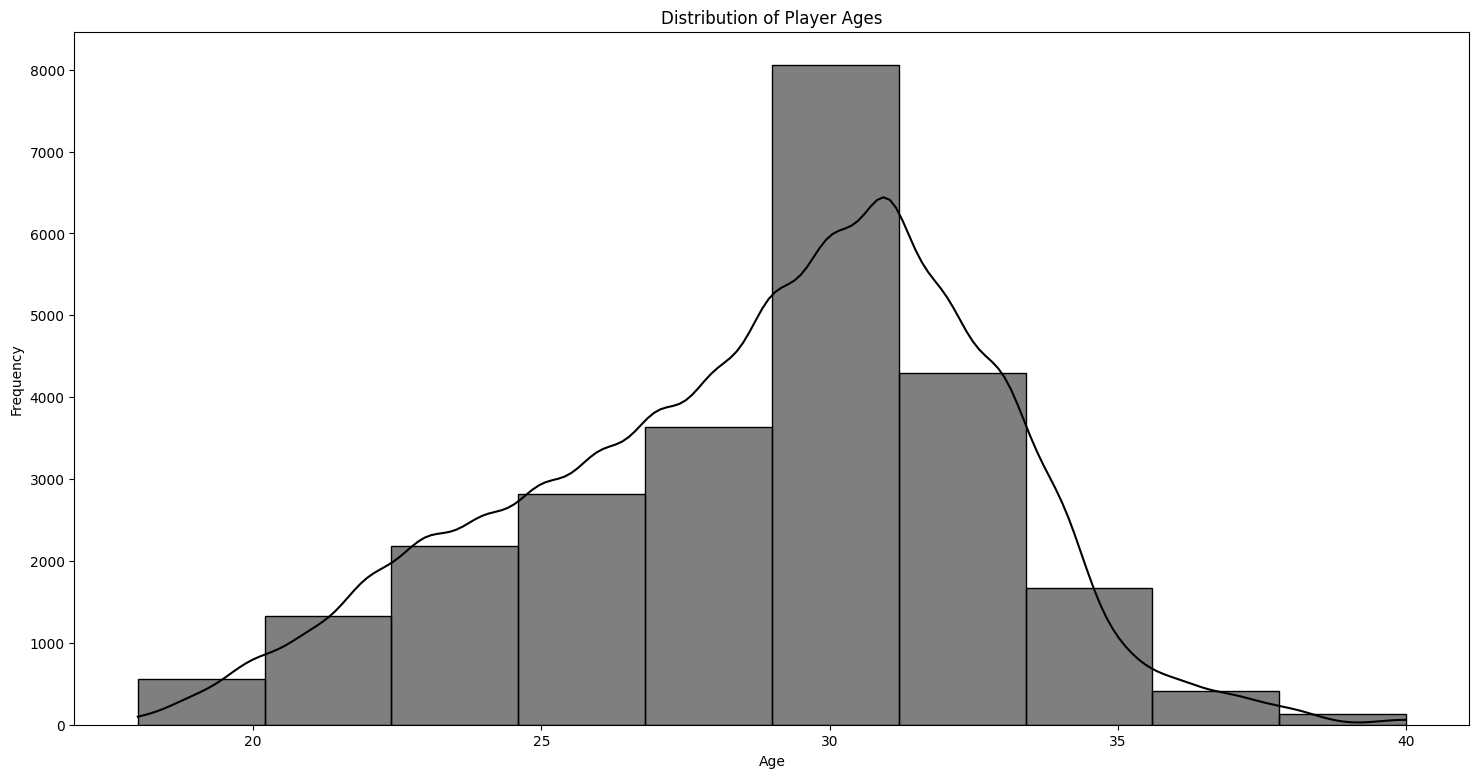

In [76]:
plt.figure(figsize=(18,9))
sns.histplot(data=df,x='last_age',bins=10,color='black',kde=True)
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

In [35]:
df['last_age'].describe()

,last_age
count,25074.000000
mean,28.776621
std,3.879922
min,18.000000
25%,26.000000
50%,29.000000
75%,32.000000
max,40.000000


#Observations


1.   Most players are of Age 31.
2.   Age group from 29 to 31 has highest number of individuals falling in that group.
1.   There are very few players in the age bracket of 38 to 40.

#Business Insight
The shows that Age group 29-31 is where most players of franchises fall. And also the amount to players quickly falls past 34 which tell us that the average span of a player career is from 25-32 after that only few remain. This tell us that franchises should have a proper system to hire young talents at young age train them and get benefit from them in their peak years.





#Question Number 3
Which player positions/teams have the highest number of players?

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'carlton blues'),
  Text(1, 0, 'collingwood magpies'),
  Text(2, 0, 'essendon bombers'),
  Text(3, 0, 'north melbourne kangaroos'),
  Text(4, 0, 'st kilda saints'),
  Text(5, 0, 'richmond tigers'),
  Text(6, 0, 'brisbane lions'),
  Text(7, 0, 'west coast eagles'),
  Text(8, 0, 'fremantle dockers'),
  Text(9, 0, 'hawthorn hawks'),
  Text(10, 0, 'melbourne demons'),
  Text(11, 0, 'port adelaide power'),
  Text(12, 0, 'western bulldogs'),
  Text(13, 0, 'sydney swans'),
  Text(14, 0, 'adelaide crows'),
  Text(15, 0, 'geelong cats'),
  Text(16, 0, 'gold coast suns'),
  Text(17, 0, 'greater western sydney giants'),
  Text(18, 0, 'brisbane bears'),
  Text(19, 0, 'fitzroy lions')])

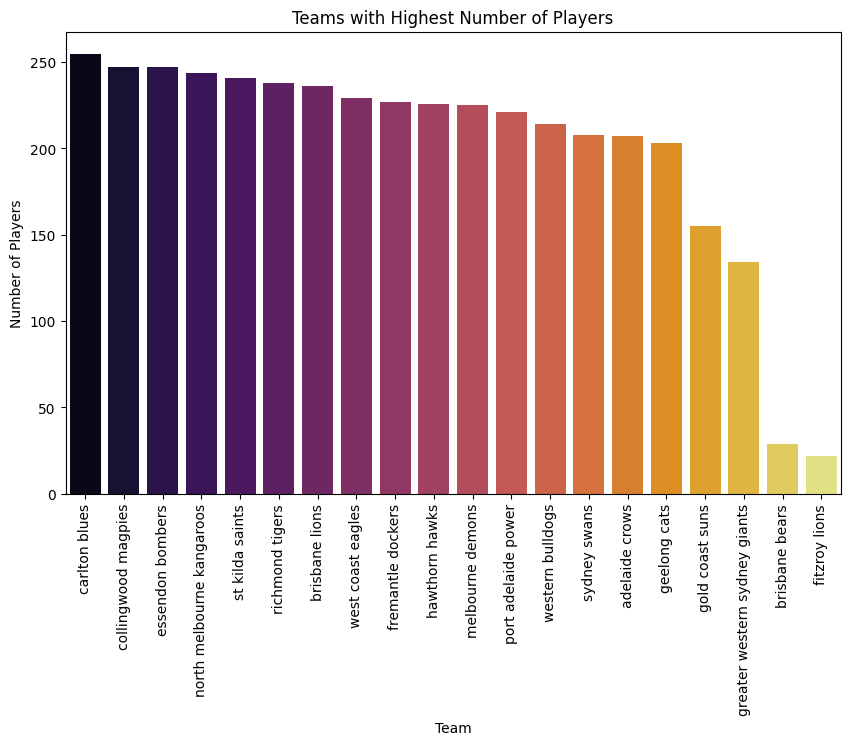

In [74]:
team_player_counts=df.groupby('team')['player_id'].nunique().sort_values(ascending=False).reset_index()
team_player_counts.columns=['team','unique_players']
plt.figure(figsize=(10,6))
sns.barplot(data=team_player_counts,x='team',y='unique_players',hue='team',palette='inferno')
plt.title('Teams with Highest Number of Players')
plt.xlabel('Team')
plt.ylabel('Number of Players')
plt.xticks(rotation=90)

#Observations


1.   Team with most players is carlton blues with 253 players.
2.   Fitzroy lions has the least amount of players.
1.   Only 4 teams have less than 200 players rest have more than that.

#Business Insight
The older clubs have more players because they have played more seasons than the new ones.This graph basically shows that every team is using new players every season and alot of players retire also. So, this graph can only show that teams usually turnover their squad every season.





#Question 4
How does player weight vary across different teams?

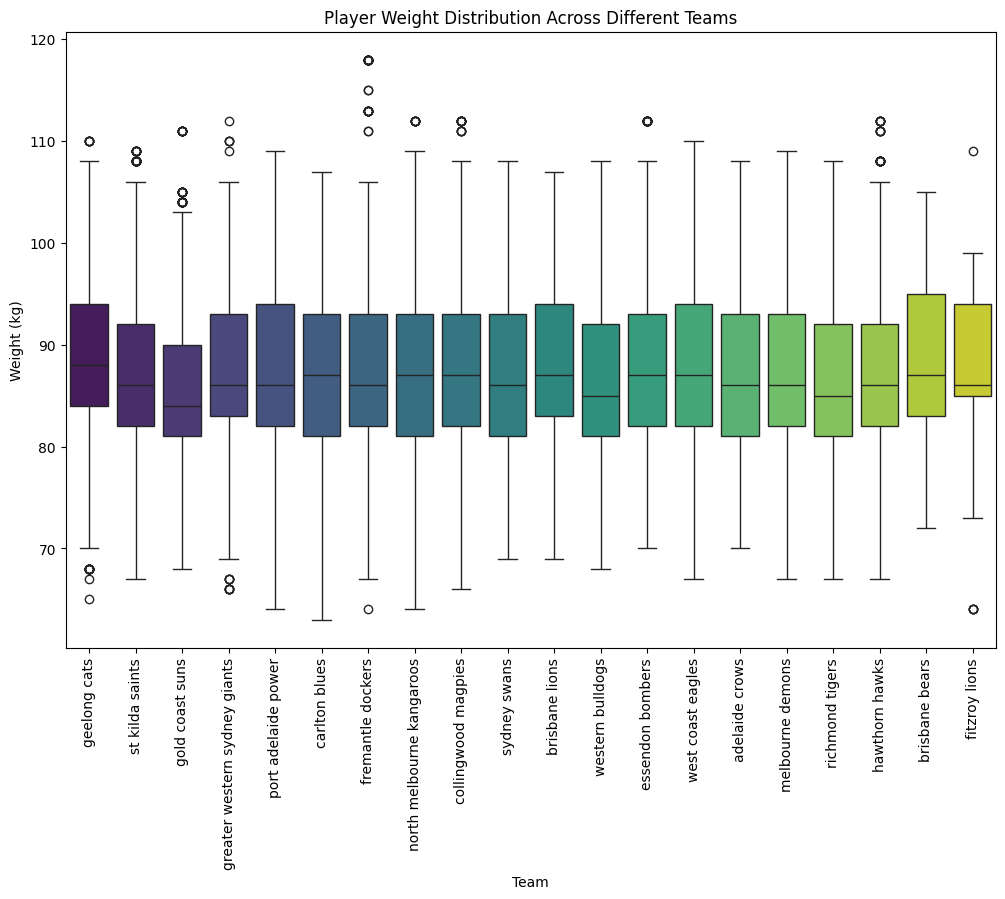

In [77]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='team', y='weight', hue='team', palette='viridis')
plt.title('Player Weight Distribution Across Different Teams')
plt.xlabel('Team')
plt.ylabel('Weight (kg)')
plt.xticks(rotation=90)
plt.show()

#Observations

1.   The median weight for most teams is relatively similar, generally hovering around the high 80kg to low 90kg range.
2.   Their is not a lot of difference between players weight of all the clubs. No effect of any old or new club.
1.   There are only a few outliers for some teams.

#Business Insight
This graph shows the median weight across all the teams is around 84-88kg.
And the number of outliers is also identical to some extent. It shows all teams are signing players of the same build. No lighter or heavier except a few exemptions.





#Question Number 5
Which teams have the highest average fantasy points?

Text(0, 0.5, 'Team')

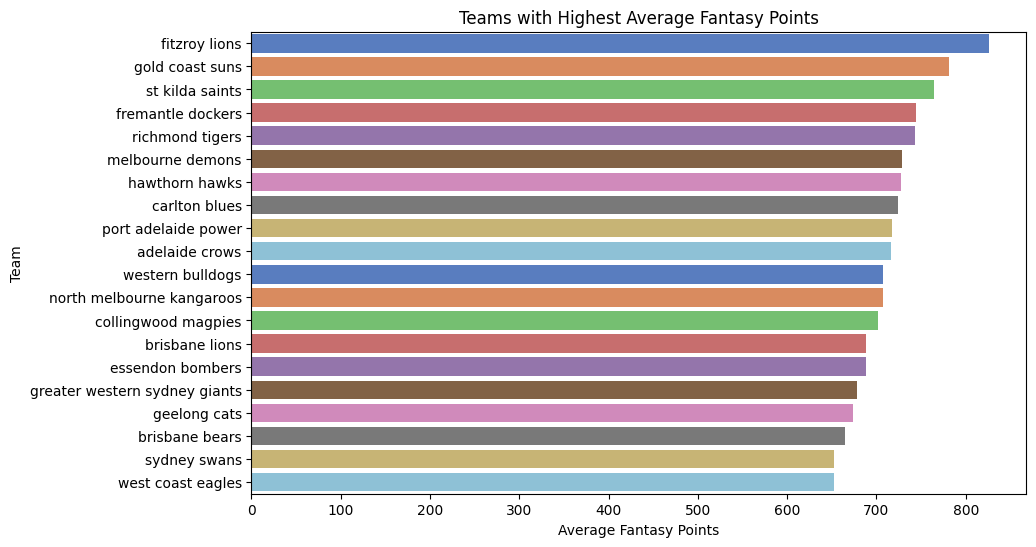

In [58]:
team_fantasy=df.groupby('team')['total_fantasy_points'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=team_fantasy,x='total_fantasy_points',y='team',hue='team',palette='muted')
plt.title('Teams with Highest Average Fantasy Points')
plt.xlabel('Average Fantasy Points')
plt.ylabel('Team')

#Observations


1.   The First Key Observation I got is that fitzroy lions has the highest number of fantasy points than other teams.
2.   Most established teams fall within a competitive range of 650 to 780 average fantasy points.
1.   West Coast Eagles and Sydney Swans appear at the lower end of the graph.

# Business Insight

High average fantasy points in smaller or newer samples (like the Fitzroy Lions or Gold Coast Suns) indicate that individual player efficiency does not always correlate with club longevity or total games played. For talent scouts and sponsors, this suggests that high-value 'stat-producing' players can be found in emerging or less established markets, providing a high return on investment regardless of the team's historical standing.





#Question Number 6
Who are the Top 15 goal scorers?

Text(0, 0.5, 'Player Name')

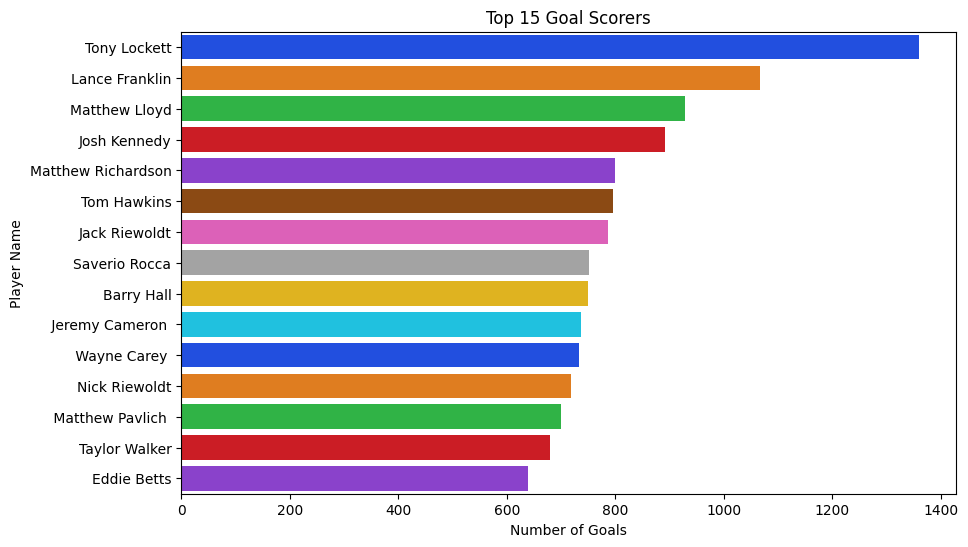

In [60]:
top_scorers=df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(15).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_scorers,x='goals',y='player_name',hue='player_name',palette='bright')
plt.ylabel('Player Name')
plt.title('Top 15 Goal Scorers')
plt.xlabel('Number of Goals')
plt.ylabel('Player Name')

#Observations


1.   Tony Lockett is the highest goal scorer by a significant margin, being the only player in the dataset to exceed 1,300 goals.
2.   Lance Franklin is the only other player to cross the 1,000-goal milestone in this group.
1.   The gap between the 5th and 15th spots is relatively narrow, with goal counts ranging from roughly 800 down to 640.

#Business Insight
This graph shows the top performer of the league ( Tony Lockett ). It tells us that elite goal scoring talent is extremely rare. And top 2 players surpass the rest by a huge margin. From 5 to 15 it is a tough competition.
So if someone is looking players for his franchises then they should target players with goals more than 750 atleast. If they want a great forward player for their team.





#Question Number 7
How many records are available for each season?

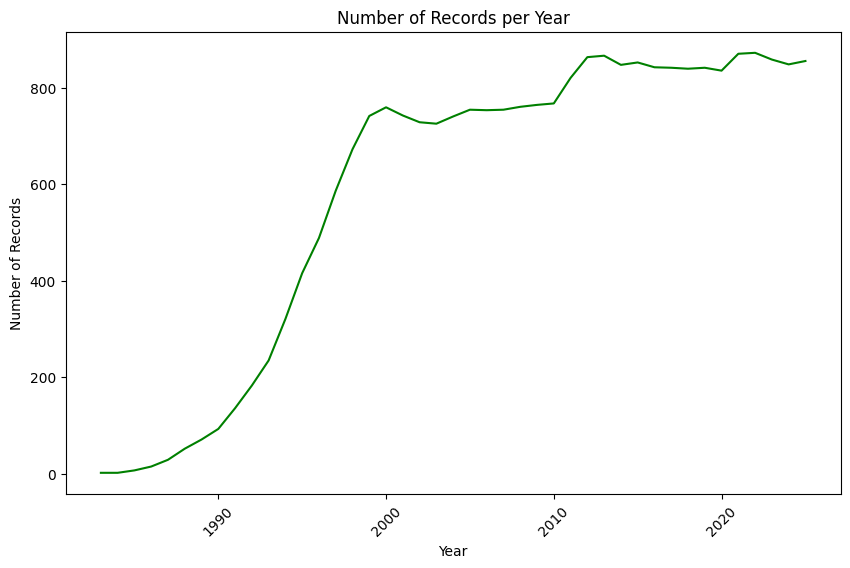

In [55]:
records_per_year=df.groupby('year').size().reset_index(name='record_count')
plt.figure(figsize=(10,6))
sns.lineplot(x='year', y='record_count', data=records_per_year, color='green')
plt.xticks(rotation=45)
plt.title('Number of Records per Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.show()


#Observations


1.   There is a significant upward trend in the number of records available from the early 1980s through to the mid-2000s, reflecting better data collection and perhaps expansion of the league.
2.   From approximately 2012 onwards, the number of records stabilizes around 840-870 per year.
1.   The years prior to 1990 have very few records (starting with just 2 in 1983), indicating that this dataset is primarily focused on or populated by more recent historical data.

# Business Insight

The sharp increase in records from the 1990s to the 2010s signifies a transition into the 'Big Data Era' of sports analytics. For businesses like sports betting, broadcasting, or performance consulting, this trend indicates that historical comparisons before 1990 may lack statistical significance due to data scarcity. Conversely, the high density data from the last decade provides a robust foundation for building high accuracy machine learning models to predict player performance and injury risks.




